In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models,layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Input,Dropout
import matplotlib.pyplot as plt

In [3]:
#增加图片增强 在原有的数据集上 怎么扩展更多的数据集呢 就能让模型 见过 更多变形的图片
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range = 20, #旋转的度数
    width_shift_range=0.1, #水平平移
    height_shift_range=0.1, #垂直平移
    shear_range = 0.2, #随机错切变换
    zoom_range = 0.2, #随机缩放
    horizontal_flip=True, #随机水平翻转
    fill_mode='nearest'
)

In [4]:
train_generator = datagen.flow_from_directory(
    './Files',
    target_size=(150,150),
    batch_size=128,
    class_mode='binary',
    subset='training',
    shuffle=True
)
validation_generator = datagen.flow_from_directory(
    './Files',
    target_size=(150,150),
    batch_size=128,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [5]:
# 获取一个批次标签和数据
images,labels = next(train_generator)

In [6]:
images.shape

(128, 150, 150, 3)

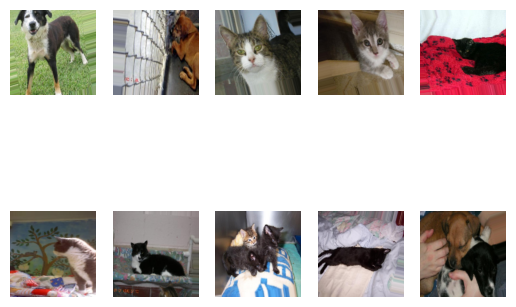

In [7]:
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')

In [8]:
# 建立卷积神经网络模型
model = Sequential([
    Input(shape=(150,150,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(512,activation='relu'),
    #随机丢弃一些
    Dropout(0.3),
    #输出层
    Dense(1,activation='sigmoid')
])

In [9]:
#学习率 修改的低一点 默认是0.001 修改为0.0001
#训练次数多一点
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
#设置早停 机制 是一种防止过拟合的技术
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss', #监控验证集上面的损失
    patience=3, #连续三轮训练 损失不下降
    min_delta = 0.001, #只要损失下降达到了0.001 就算是下降
    verbose = 1,
    restore_best_weights =True #恢复最佳权重
)

In [14]:
history = model.fit(train_generator,epochs=100,validation_data=validation_generator,callbacks=early_stopping)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.6166 - loss: 0.6584 - val_accuracy: 0.6125 - val_loss: 0.6511
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.6450 - loss: 0.6405 - val_accuracy: 0.6187 - val_loss: 0.6378
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.6650 - loss: 0.6170 - val_accuracy: 0.6525 - val_loss: 0.6178
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step - accuracy: 0.6787 - loss: 0.6028 - val_accuracy: 0.6888 - val_loss: 0.5976
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.6966 - loss: 0.5833 - val_accuracy: 0.6850 - val_loss: 0.5895
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.7066 - loss: 0.5742 - val_accuracy: 0.7013 - val_loss: 0.5761
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.7066 - loss: 0.5727 - val_accuracy: 0.6862 - val_loss: 0.5828
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.7119 - loss: 0.5594 - val_accuracy: 0.6850 

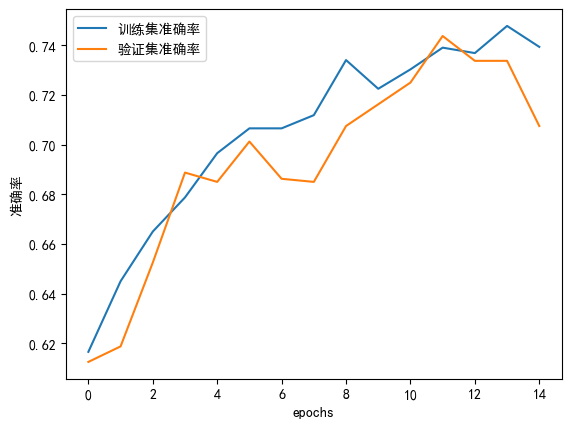

In [15]:
#可视化
#配置中文显示
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.plot(history.history['accuracy'],label='训练集准确率')
plt.plot(history.history['val_accuracy'],label='验证集准确率')
plt.xlabel('epochs')
plt.ylabel('准确率')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step


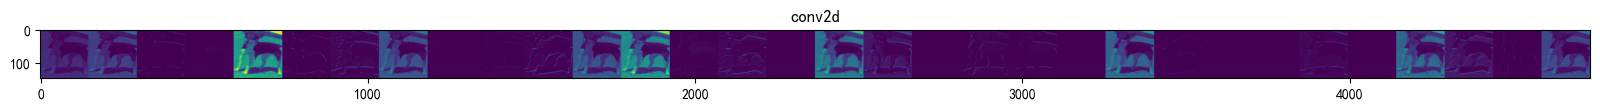

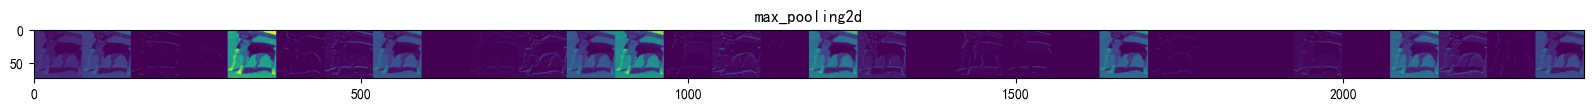

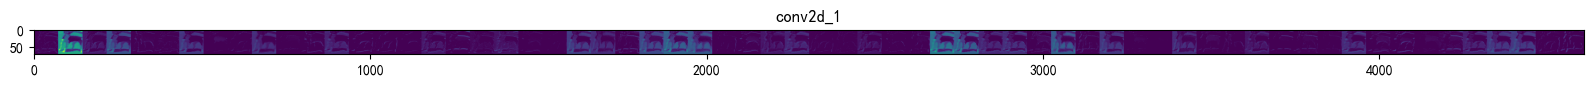

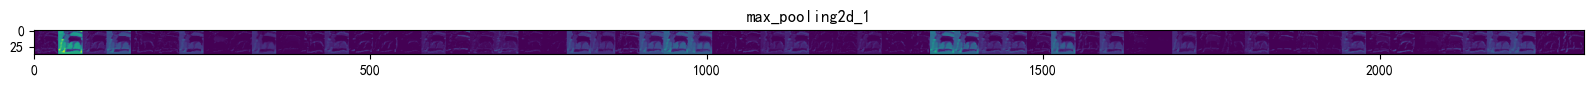

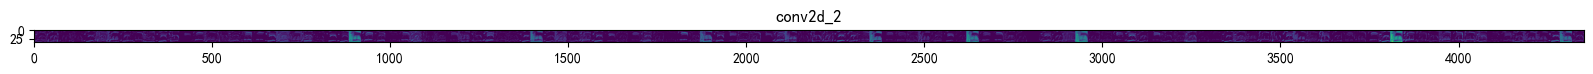

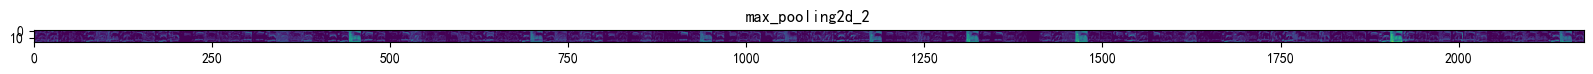

In [16]:
# cnn卷积层的 可视化 层
import random
import numpy as np
successive_outputs = [layer.output for layer in model.layers]
visualization_model = tf.keras.models.Model(inputs=model.inputs,outputs=successive_outputs)

#获取一个批次的图像和标签
x_batch,y_batch = next(train_generator)

#随机选择一张图片
img_index = random.randint(0,x_batch.shape[0] - 1)
img = x_batch[img_index].reshape(1,150,150,3)

#获取每一层的激活图
successive_feature_maps = visualization_model.predict(img)

#获取每层的名称
layer_names = [layer.name for layer in model.layers]

#可视化每一层的激活图
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4: #跳过非卷积层
        n_features = feature_map.shape[-1] #特征图数量
        size = feature_map.shape[1] #特征图的尺寸(假设是方形)

        display_grid = np.zeros((size,size * n_features)) #创建一个空的二维数组 display_grid,用于将每个特征图拼接成一个大的图像
        for i in range(n_features):
            x = feature_map[0,:,:,i] #选择读一个样本 (假设批次大小为 1), 然后获取第i个特征图的内容
            display_grid[:,i*size:(i+1)*size]=x #为第i个特征图分配一个对应的区域 一行代码的目的是将每个特征图的内容 x 按照列的方向拼接到 display_grid

        scale = 20. / n_features
        plt.figure(figsize=(scale*n_features,scale))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto',cmap='viridis')
        plt.show()

In [17]:
model.save('cat_dog_model.keras')

In [18]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [26]:
#测试一下模型
from tensorflow.keras.preprocessing import image
#导入模型
model_new = models.load_model('cat_dog_model.keras')

img_1 = '猫.jpg'
img = image.load_img(img_1,target_size=(150,150))
#需要将图片转换为numpy 的数组
img_array = image.img_to_array(img)
#img_array.shape
img_array = img_array.reshape(1,150,150,3)
#img_array.shape
img_array = img_array / 255.0

prediction = model_new.predict(img_array)
#prediction
print('预测的结果是:','狗' if prediction[0]>0.5 else '猫')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
预测的结果是: 猫
